<a href="https://colab.research.google.com/github/Yangel300/BreathIA/blob/main/WEEF1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pandas

In [1]:
import os

# Clone the GitHub repository
!git clone https://github.com/SJTU-YONGFU-RESEARCH-GRP/SPRSound.git




Cloning into 'SPRSound'...
remote: Enumerating objects: 16393, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 16393 (delta 20), reused 20 (delta 18), pack-reused 16367 (from 1)
Receiving objects: 100% (16393/16393), 717.49 MiB | 22.36 MiB/s, done.
Resolving deltas: 100% (7916/7916), done.
Updating files: 100% (35672/35672), done.


In [75]:
import pandas as pd
datapath="/content/SPRSound/Patient Summary/Grand_Challenge'23_patient_summary.csv"

data=pd.read_csv(datapath)

data


,patient_num,disease,age,gender
0,64634665,Bronchitis,3.3,M
1,00014365,Control group,4.3,F
2,40844382,Bronchitis,4.8,F
3,40876967,Bronchitis,4.3,M
4,40884475,Pneumonia (non-severe),3.8,F
...,...,...,...,...
89,66353843,Bronchitis,3.2,F
90,66365613,Control group,10.3,F
91,66366234,Bronchitis,3.8,F
92,66366279,Bronchitis,4.9,M


/tmp/ipykernel_3250/2179600789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y='disease', order=data['disease'].value_counts().index, palette='viridis')


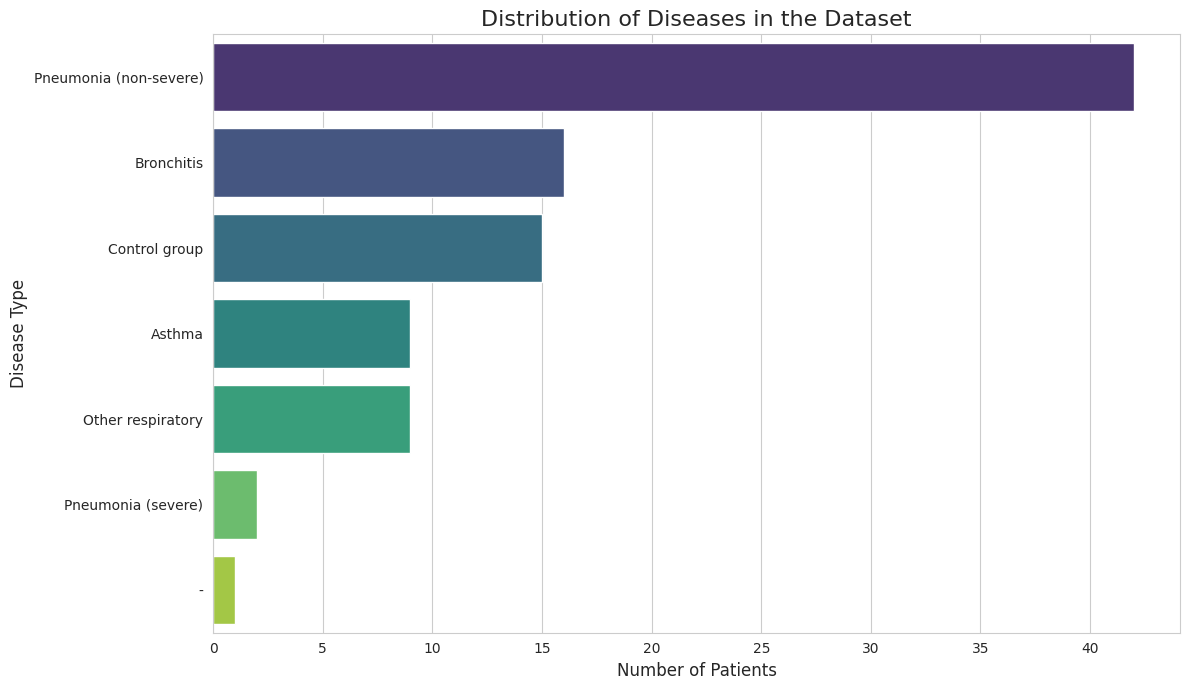

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plot
sns.set_style("whitegrid")

# Create the bar plot (acting as a histogram for categorical data)
plt.figure(figsize=(12, 7))
sns.countplot(data=data, y='disease', order=data['disease'].value_counts().index, palette='viridis')
plt.title('Distribution of Diseases in the Dataset', fontsize=16)
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Disease Type', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
trainfolder1="/content/SPRSound/BioCAS2022"
trainfolder2="/content/SPRSound/BioCAS2023"
trainfolder3="/content/SPRSound/BioCAS2024"
testfolder="/content/SPRSound/BioCAS2025"

#Background

In [16]:
import json

json_file_test="/content/SPRSound/BioCAS2022/test2022_json/inter_test_json/65118898_0.7_0_p1_4170.json"

# Open and load the JSON file
with open(json_file_test, 'r') as f:
    json_data = json.load(f)

# Print the content of the JSON file
print(json.dumps(json_data, indent=4))

{
    "record_annotation": "CAS",
    "event_annotation": [
        {
            "start": "29",
            "end": "437",
            "type": "Wheeze"
        },
        {
            "start": "964",
            "end": "1340",
            "type": "Wheeze"
        },
        {
            "start": "1787",
            "end": "2175",
            "type": "Wheeze"
        },
        {
            "start": "2579",
            "end": "2948",
            "type": "Wheeze"
        },
        {
            "start": "3326",
            "end": "3783",
            "type": "Wheeze"
        },
        {
            "start": "4324",
            "end": "4967",
            "type": "Wheeze"
        },
        {
            "start": "5537",
            "end": "6360",
            "type": "Wheeze"
        },
        {
            "start": "7041",
            "end": "7907",
            "type": "Wheeze"
        }
    ]
}


### Key Features from JSON Data

In [17]:
# Extracting record annotation
record_annotation = json_data.get('record_annotation')
print(f"Record Annotation: {record_annotation}")

# Extracting event annotations
event_annotations = json_data.get('event_annotation', [])
print(f"Number of Events: {len(event_annotations)}")

# Get unique event types and their counts
event_types = [event.get('type') for event in event_annotations]
from collections import Counter
event_type_counts = Counter(event_types)
print("Event Type Counts:")
for event_type, count in event_type_counts.items():
    print(f"- {event_type}: {count}")

# Calculate duration for each event and total duration
total_duration = 0
print("Event Durations:")
for i, event in enumerate(event_annotations):
    start = int(event.get('start', 0))
    end = int(event.get('end', 0))
    duration = end - start
    print(f"- Event {i+1} (Type: {event.get('type')}): Start={start}, End={end}, Duration={duration}")
    total_duration += duration

print(f"Total Duration of all Events: {total_duration}")

Record Annotation: CAS
Number of Events: 8
Event Type Counts:
- Wheeze: 8
Event Durations:
- Event 1 (Type: Wheeze): Start=29, End=437, Duration=408
- Event 2 (Type: Wheeze): Start=964, End=1340, Duration=376
- Event 3 (Type: Wheeze): Start=1787, End=2175, Duration=388
- Event 4 (Type: Wheeze): Start=2579, End=2948, Duration=369
- Event 5 (Type: Wheeze): Start=3326, End=3783, Duration=457
- Event 6 (Type: Wheeze): Start=4324, End=4967, Duration=643
- Event 7 (Type: Wheeze): Start=5537, End=6360, Duration=823
- Event 8 (Type: Wheeze): Start=7041, End=7907, Duration=866
Total Duration of all Events: 4330


In [23]:
record_annotation = json_data.get('record_annotation')
event_annotations= json_data.get('event_annotation', [])
print(f"Event Annotation: {event_annotations}")
number_of_events=len(event_annotations)

for i in range(number_of_events):
  event_type=event_annotations[i].get('type')
  event_start=event_annotations[i].get('start')
  event_end=event_annotations[i].get("end")
  print(event_type,event_start,event_end)

Event Annotation: [{'start': '29', 'end': '437', 'type': 'Wheeze'}, {'start': '964', 'end': '1340', 'type': 'Wheeze'}, {'start': '1787', 'end': '2175', 'type': 'Wheeze'}, {'start': '2579', 'end': '2948', 'type': 'Wheeze'}, {'start': '3326', 'end': '3783', 'type': 'Wheeze'}, {'start': '4324', 'end': '4967', 'type': 'Wheeze'}, {'start': '5537', 'end': '6360', 'type': 'Wheeze'}, {'start': '7041', 'end': '7907', 'type': 'Wheeze'}]
Wheeze 29 437
Wheeze 964 1340
Wheeze 1787 2175
Wheeze 2579 2948
Wheeze 3326 3783
Wheeze 4324 4967
Wheeze 5537 6360
Wheeze 7041 7907


In [24]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
def graph_audio(audio="audio", colorx="blue",y=None, sr=None):
  if y is None and sr is None:
    y,sr=librosa.load(audio)
  y=y/np.max(np.abs(y))
  dt=y.size/sr
  plt.figure(figsize=(3.8, 2.8))
  plt.subplot()
  plt.grid()
  plt.xlim(0,dt)
  plt.ylim(-1.1,1.1)
  librosa.display.waveshow(y, sr=sr, color=colorx)
  plt.xlabel('tiempo [s]')
  plt.ylabel('amplitud[/]')
  return y,22050,dt

<Figure size 800x400 with 0 Axes>

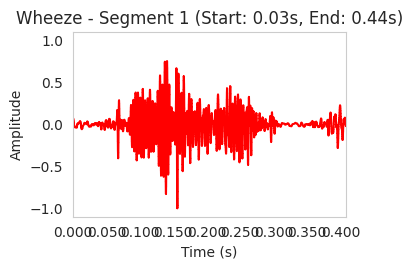

<Figure size 800x400 with 0 Axes>

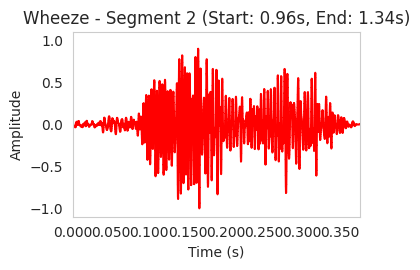

<Figure size 800x400 with 0 Axes>

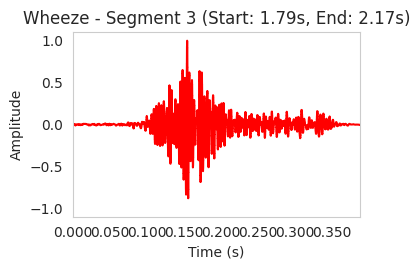

<Figure size 800x400 with 0 Axes>

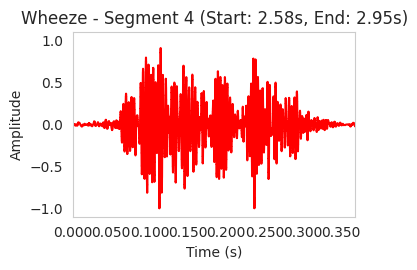

<Figure size 800x400 with 0 Axes>

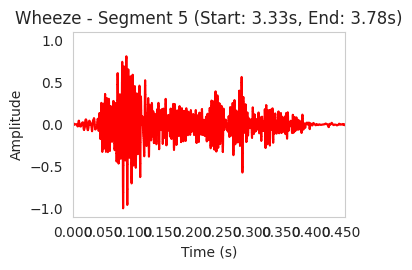

<Figure size 800x400 with 0 Axes>

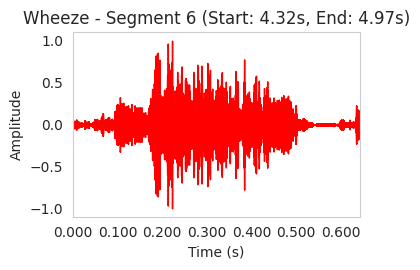

<Figure size 800x400 with 0 Axes>

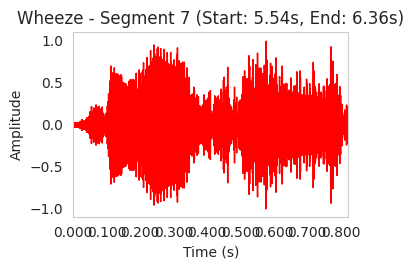

<Figure size 800x400 with 0 Axes>

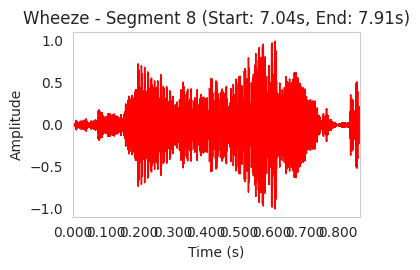

In [27]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

audio_path = "/content/SPRSound/BioCAS2022/test2022_wav/65118898_0.7_0_p1_4170.wav"

# Load the full audio file
y_full, sr_full = librosa.load(audio_path)

# Assuming event_annotations is already loaded from the JSON data
# and contains dictionaries like {'start': '29', 'end': '437', 'type': 'Wheeze'}

# Iterate through each event and plot its segment
for i, event in enumerate(event_annotations):
    event_type = event.get('type', 'Unknown Event')
    start_ms = int(event.get('start', 0))
    end_ms = int(event.get('end', 0))

    # Convert milliseconds to seconds
    start_s = start_ms / 1000.0
    end_s = end_ms / 1000.0

    # Convert seconds to sample indices
    start_sample = int(start_s * sr_full)
    end_sample = int(end_s * sr_full)

    # Extract the audio segment
    y_segment = y_full[start_sample:end_sample]

    # Plot the segment using the graph_audio function
    # graph_audio expects y and sr directly if audio argument is not a path
    plt.figure(figsize=(8, 4))
    # Call the helper function for plotting
    graph_audio(y=y_segment, sr=sr_full, colorx='red')
    plt.title(f'{event_type} - Segment {i+1} (Start: {start_s:.2f}s, End: {end_s:.2f}s)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

In [71]:
def slice_audio(audio="audio"):
  audio_path=f"{audio}.wav"
  json_path=f"/content/SPRSound/BioCAS2022/test2022_json/inter_test_json/65118898_0.7_0_p1_4170.json"
  with open(json_path, 'r') as f:
    json_data = json.load(f)
  y_full, sr_full = librosa.load(audio_path)
  event_annotations= json_data.get('event_annotation', [])
  sliced_audios=[]
  for event in event_annotations:
    start_time=int(event.get('start'))/1000
    end_time=int(event.get('end'))/1000
    start_sample = int(start_time * sr_full)
    end_sample = int(end_time * sr_full)
    y_segment = y_full[start_sample:end_sample]
    sliced_audios.append(y_segment)
  return sliced_audios



In [70]:
y_full, sr_full = librosa.load("/content/SPRSound/BioCAS2022/test2022_wav/65118898_0.7_0_p1_4170.wav")
json_path=f"/content/SPRSound/BioCAS2022/test2022_json/inter_test_json/65118898_0.7_0_p1_4170.json"
with open(json_path, 'r') as f:
  json_data = json.load(f)
event_annotations= json_data.get('event_annotation', [])
for event in event_annotations:
  start_time=int(event.get('start'))/1000
  end_time=int(event.get('end'))/1000
  start_sample = int(start_time * sr_full)
  end_sample = int(end_time * sr_full)
  print(start_sample,end_sample)

22050
639 9635
21256 29547
39403 47958
56866 65003
73338 83415
95344 109522
122090 140238
155254 174349


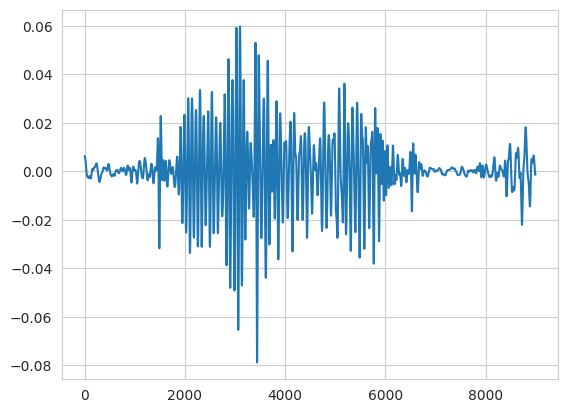

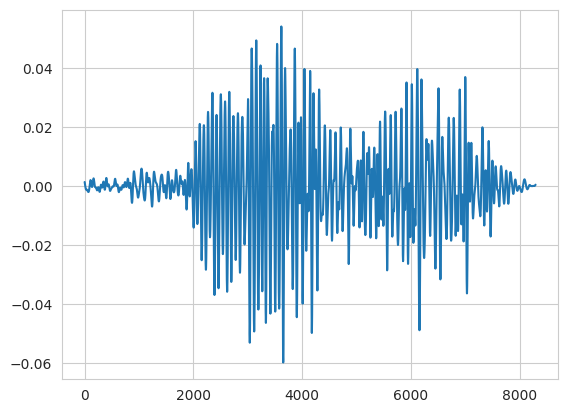

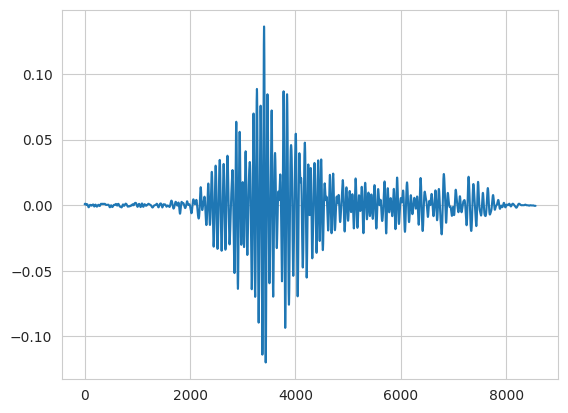

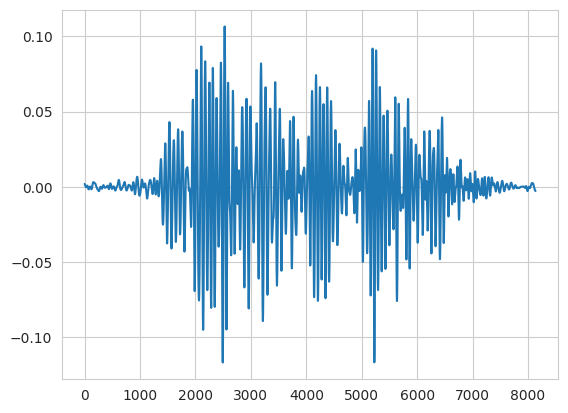

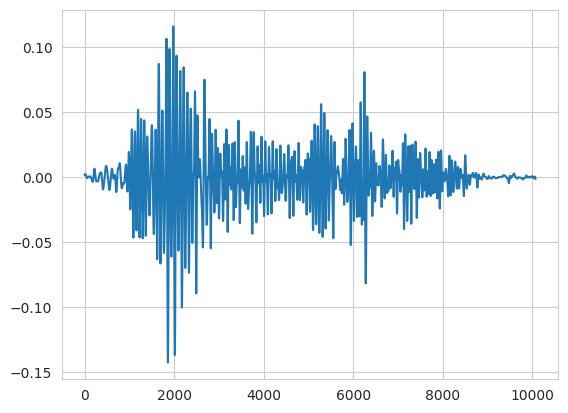

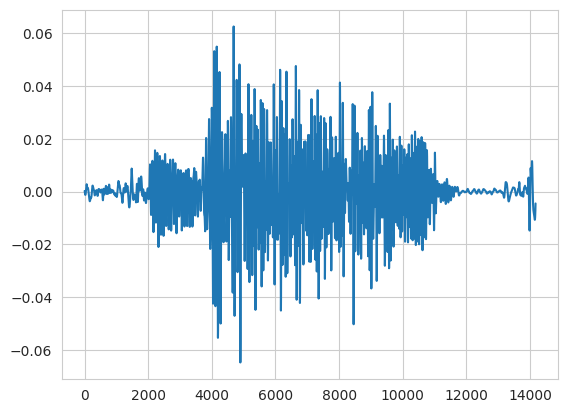

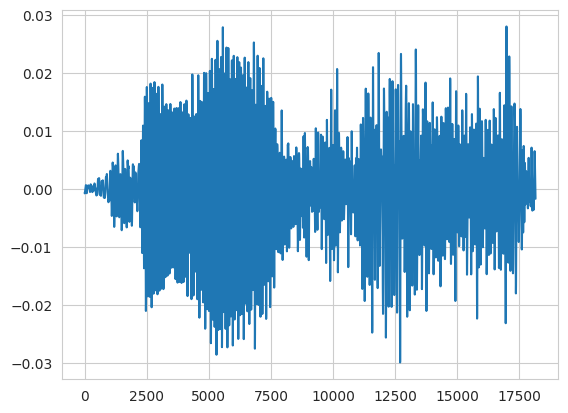

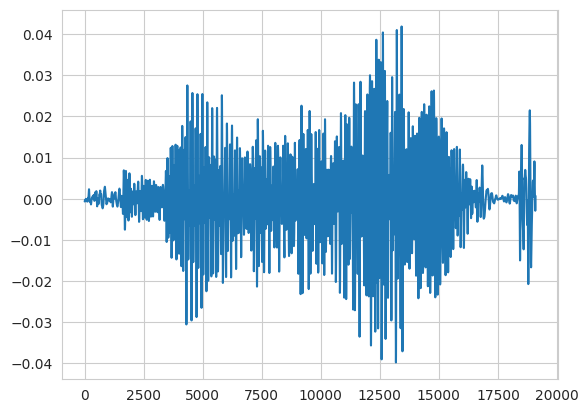

In [74]:
a=slice_audio("/content/SPRSound/BioCAS2022/test2022_wav/65118898_0.7_0_p1_4170")
for i in a:
  plt.plot(i)
  plt.show()